# Technical Assessment: Multi-endpoint ADME Prediction (OpenADMET Expansion Data)

**Goal.** Build, validate and critically compare several models that predict physicochemical and ADME properties of drug-like molecules from their structure alone.

**How to use this notebook.** Sections 1–3 are runnable scaffolding (data loading, EDA starters, featurization and metric helpers). Sections 4–8 contain *prompts and stubs*: you write the modelling code and, just as importantly, the written interpretation. Replace every `TODO` and every **Your analysis** cell with your own work.

> A well-reasoned comparison of four models on a subset of endpoints beats a shallow sweep over all ten.

## 1. Problem description

Given a molecule (SMILES), predict its measured property values. The data come from the OpenADMET–ExpansionRx blind challenge: real late-stage-optimisation ADMET measurements (>7,000 molecules) released by Expansion Therapeutics. Molecule IDs reflect measurement order, so they carry time information. Official data description: <https://huggingface.co/datasets/openadmet/openadmet-expansionrx-challenge-train-data>.

| Column | Property | Typical units | Notes |
|---|---|---|---|
| `LogD` | Lipophilicity (logD) | log units | closest measured analogue of **logP**; ionisable compounds make logD ≠ logP |
| `KSOL` | Kinetic solubility | µM | the ML-ready release keeps only in-range values, so the top of the range (~330 µM) is truncated |
| `HLM CLint` | Human liver microsomal intrinsic clearance | mL/min/kg | right-skewed |
| `MLM CLint` | Mouse liver microsomal intrinsic clearance | mL/min/kg | right-skewed |
| `Caco-2 Permeability Papp A>B` | Apparent permeability | 10⁻⁶ cm/s | right-skewed |
| `Caco-2 Permeability Efflux` | Efflux ratio (B>A / A>B) | ratio | very heavy tail |
| `MPPB` / `MBPB` / `MGMB` | Mouse plasma / brain / gastrocnemius muscle binding | % unbound | bounded 0–100, sparse; low value = highly bound |

**Things to notice before you model (you will be asked to discuss them later):**

1. **Multi-task with missing labels.** Not every compound was run in every assay; coverage ranges from ~100% (`KSOL`) to <5% (`MGMB`).
2. **Skewed, bounded targets.** Several endpoints span orders of magnitude (clearance, efflux, % unbound). The scale you model and score them on is your decision.
3. **Different scales and noise levels per endpoint.** Any metric you aggregate across endpoints needs thought.
4. **You choose the metrics.** There is no prescribed score for this assessment. You pick the metric(s), justify why they fit the use-case, and apply them consistently to all four models (see §4.0.2).
5. **Train/test are disjoint** (no shared molecules). Check *how* different they are, because that determines how much you can trust a random CV.

**Task.** For a chosen set of endpoints (at least `LogD`, `KSOL`, and two clearance/permeability/binding endpoints), fit and compare four model families:

| # | Model | Input representation |
|---|---|---|
| A | **Ridge regression** | fingerprints and/or RDKit descriptors |
| B | **Boosted trees** (LightGBM / XGBoost) | fingerprints and/or RDKit descriptors |
| C | **Chemprop** (D-MPNN) | molecular graph |
| D | **Your own model** | your choice, see §4.4 |

**Rules.** Use `data/expansion_train.csv` for *all* fitting, tuning and model selection. `data/expansion_test.csv` is touched **once**, in §6.

## 2. Setup and data loading

In [73]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from scipy.stats import spearmanr, pearsonr, kendalltau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
RDLogger.DisableLog("rdApp.*")

SEED = 0
# adding this so i don't go back and forth trying to read what the units measure
TARGETS = ["lipophilicity_logD", "solub_uM",
           "human_clear_mL_min_kg", "mouse_clear_mL_min_kg",
           "permeab_10^-6cm_s", "efflux_ratio",
           "plasma_bind_p_unbound", "brain_bind_p_unbound",
           "calf_bind_p_unbound"]
TARGET_COLUMNS = ["LogD", "KSOL", "HLM CLint", "MLM CLint",
                  "Caco-2 Permeability Papp A>B", "Caco-2 Permeability Efflux",
                  "MPPB", "MBPB", "MGMB"]

def load(path):
    df = pd.read_csv(path)
    for target, source in zip(TARGETS, TARGET_COLUMNS):  # coerce to numeric, blanks -> NaN
        df[source] = pd.to_numeric(df[source], errors="coerce")
        df[target] = df[source]  # keep CSV columns for existing notebook references
        df = df.drop(source, axis=1)
    df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
    assert df["mol"].notna().all(), "unparsable SMILES"
    return df

data_dir = Path.cwd() / "data"
train = load(data_dir / "expansion_train.csv")
test  = load(data_dir / "expansion_test.csv")   # do NOT look at test labels until section 6
print(train.shape, test.shape)
train.drop(columns="mol").head()

(4798, 12) (2282, 12)


,Molecule Name,SMILES,lipophilicity_logD,solub_uM,human_clear_mL_min_kg,mouse_clear_mL_min_kg,permeab_10^-6cm_s,efflux_ratio,plasma_bind_p_unbound,brain_bind_p_unbound,calf_bind_p_unbound
0,E-0011933,Nc1nc2c(-c3ccccc3)cnn2cc1-c1ccccc1,4.0,0.210,99.7,6019.2,26.27,NaN,NaN,NaN,NaN
1,E-0012170,CC(C)c1ccc(CNc2nc(-c3ccccc3)cc(=O)[nH]2)cc1,4.6,0.030,14.3,974.4,2.72,NaN,NaN,NaN,NaN
2,E-0012233,FC(F)(F)Oc1cccc(-c2ccnc(Nc3ccc(CN4CCOCC4)cc3)n...,4.7,0.360,63.9,1006.1,3.69,NaN,NaN,NaN,NaN
3,E-0012239,CCc1ccc(CNc2nc(-c3ccccc3)cc(=O)[nH]2)cc1,3.5,0.158,39.4,1973.2,2.91,NaN,NaN,NaN,NaN
4,E-0012774,O=C(c1n[nH]c2cc(F)ccc12)N1CCC(Oc2ccc(C(F)(F)F)...,4.6,0.210,1.0,36.3,4.81,NaN,NaN,NaN,NaN


## 3. Exploratory data analysis

Use the starter cells, then extend them. For each prompt, write down what you found and *what it implies for modelling*.

### 3.1 Label coverage and missingness

,train_n,train_%,test_n,test_%
lipophilicity_logD,4552,94.9,2270,99.5
solub_uM,4721,98.4,2170,95.1
human_clear_mL_min_kg,3456,72.0,782,34.3
mouse_clear_mL_min_kg,4110,85.7,1170,51.3
permeab_10^-6cm_s,1956,40.8,1616,70.8
efflux_ratio,1953,40.7,1616,70.8
plasma_bind_p_unbound,1201,25.0,454,19.9
brain_bind_p_unbound,901,18.8,451,19.8
calf_bind_p_unbound,214,4.5,209,9.2


,lipophilicity_logD,solub_uM,human_clear_mL_min_kg,mouse_clear_mL_min_kg,permeab_10^-6cm_s,efflux_ratio,plasma_bind_p_unbound,brain_bind_p_unbound,calf_bind_p_unbound
lipophilicity_logD,1.00,0.34,-0.09,-0.08,0.14,0.14,-0.23,0.09,0.05
solub_uM,0.34,1.00,-0.03,-0.04,0.08,0.08,0.04,0.03,0.02
human_clear_mL_min_kg,-0.09,-0.03,1.00,0.64,0.37,0.37,0.13,0.13,-0.05
mouse_clear_mL_min_kg,-0.08,-0.04,0.64,1.00,0.32,0.32,0.13,0.18,0.08
permeab_10^-6cm_s,0.14,0.08,0.37,0.32,1.00,1.00,0.41,0.55,0.25
efflux_ratio,0.14,0.08,0.37,0.32,1.00,1.00,0.42,0.56,0.25
plasma_bind_p_unbound,-0.23,0.04,0.13,0.13,0.41,0.42,1.00,0.82,0.36
brain_bind_p_unbound,0.09,0.03,0.13,0.18,0.55,0.56,0.82,1.00,0.44
calf_bind_p_unbound,0.05,0.02,-0.05,0.08,0.25,0.25,0.36,0.44,1.00


,lipophilicity_logD,solub_uM,human_clear_mL_min_kg,mouse_clear_mL_min_kg,permeab_10^-6cm_s,efflux_ratio,plasma_bind_p_unbound,brain_bind_p_unbound,calf_bind_p_unbound
lipophilicity_logD,1.00,0.04,0.05,0.06,0.06,0.06,0.02,0.02,0.02
solub_uM,0.04,1.00,0.14,0.22,0.02,0.02,0.10,0.10,0.07
human_clear_mL_min_kg,0.05,0.14,1.00,0.24,0.44,0.44,0.41,0.41,0.22
mouse_clear_mL_min_kg,0.06,0.22,0.24,1.00,0.43,0.43,0.34,0.35,0.31
permeab_10^-6cm_s,0.06,0.02,0.44,0.43,1.00,1.00,0.32,0.32,0.20
efflux_ratio,0.06,0.02,0.44,0.43,1.00,1.00,0.32,0.32,0.20
plasma_bind_p_unbound,0.02,0.10,0.41,0.34,0.32,0.32,1.00,0.99,0.63
brain_bind_p_unbound,0.02,0.10,0.41,0.35,0.32,0.32,0.99,1.00,0.64
calf_bind_p_unbound,0.02,0.07,0.22,0.31,0.20,0.20,0.63,0.64,1.00


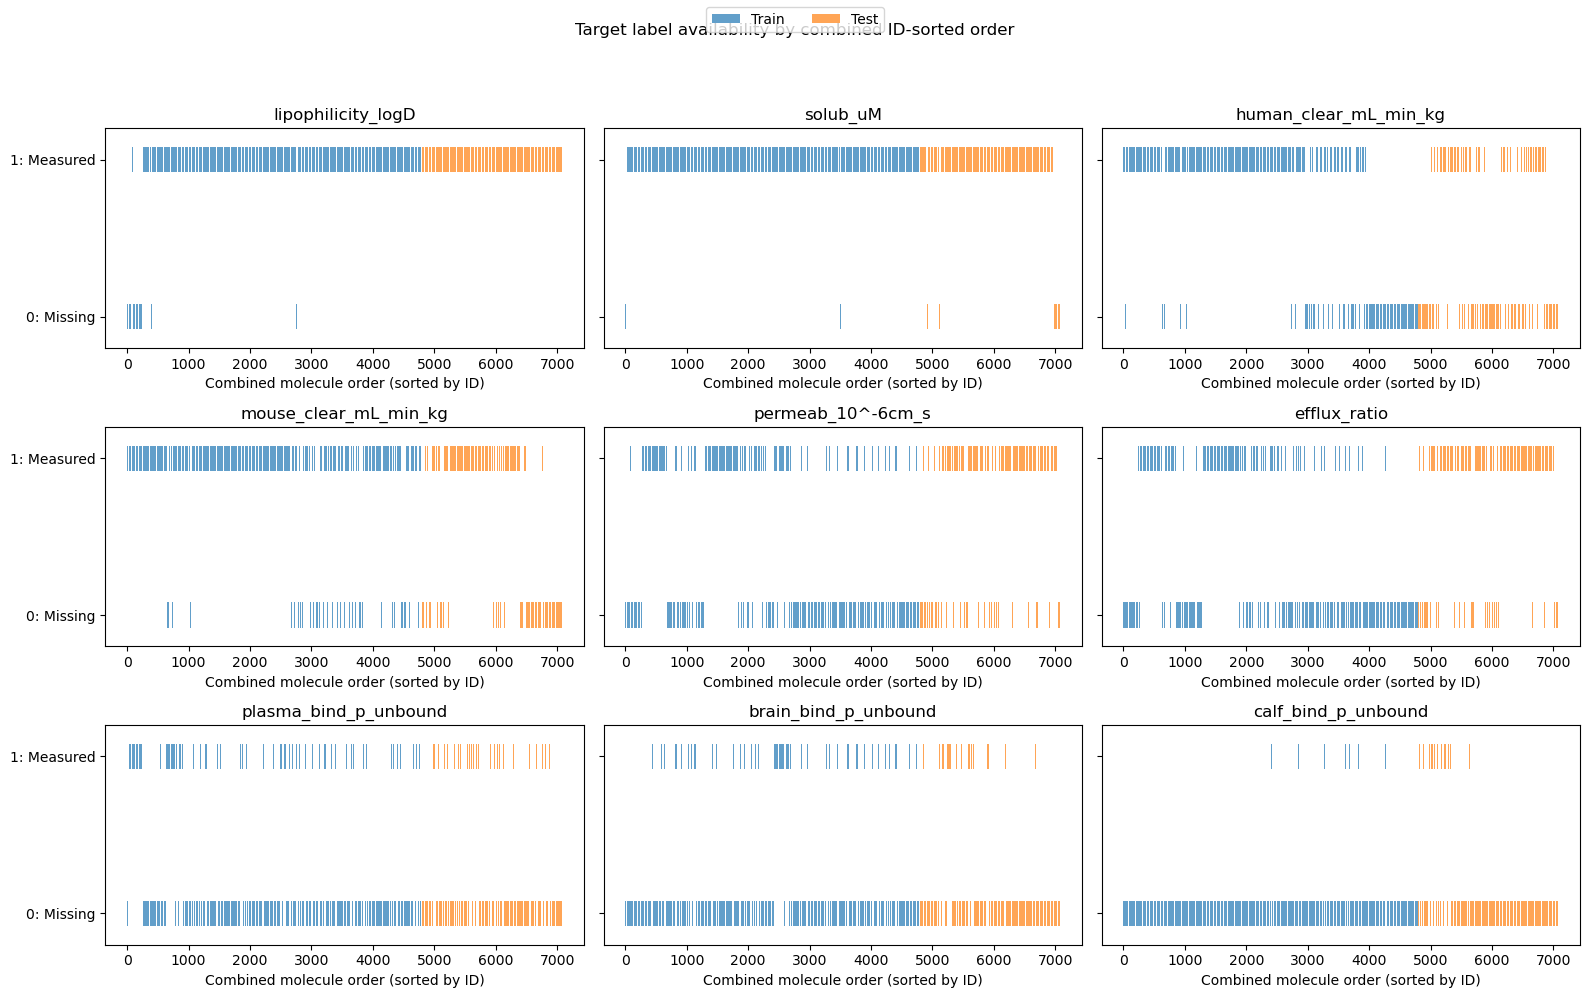

111100000    1369
111111000     984
110000000     600
111111110     592
110100000     498
011100100     141
111111111     124
110111111      79
Name: count, dtype: int64


calf_bind_p_unbound      0.059746
brain_bind_p_unbound     0.190960
plasma_bind_p_unbound    0.233757
efflux_ratio             0.504096
permeab_10^-6cm_s        0.504520
human_clear_mL_min_kg    0.598588
mouse_clear_mL_min_kg    0.745763
lipophilicity_logD       0.963559
solub_uM                 0.973305
dtype: float64

In [74]:
cov = pd.DataFrame({
    "train_n": train[TARGETS].notna().sum(),
    "train_%": (100 * train[TARGETS].notna().mean()).round(1),
    "test_n":  test[TARGETS].notna().sum(),
    "test_%":  (100 * test[TARGETS].notna().mean()).round(1),
})
display(cov)

# Correlation of Boolean target-measurement indicators (True = measured, False = missing).
train_measured = train[TARGETS].notna()
test_measured = test[TARGETS].notna()
train_measurement_corr = train_measured.corr(min_periods=2)
test_measurement_corr = test_measured.corr(min_periods=2)
display(train_measurement_corr.style.background_gradient(cmap="bwr", vmin=-1, vmax=1).format("{:.2f}"))
display(test_measurement_corr.style.background_gradient(cmap="bwr", vmin=-1, vmax=1).format("{:.2f}"))

# Which assays are measured together? (pattern of co-measurement)
pattern = train[TARGETS].notna().astype(int).astype(str).agg("".join, axis=1).value_counts().head(8)
cov["train_%"].sort_values()

# Show target-label availability in one combined ordering sorted by molecule ID.
all_molecule_ids = pd.concat([train["Molecule Name"], test["Molecule Name"]]).unique()
molecule_order = {
    molecule_id: order
    for order, molecule_id in enumerate(
        sorted(all_molecule_ids, key=lambda name: int(name.rsplit("-", 1)[1]))
    )
}
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=True)
for ax, target in zip(axes.flat, TARGETS):
    for split_name, frame, color in [("Train", train, "tab:blue"), ("Test", test, "tab:orange")]:
        row_order = frame["Molecule Name"].map(molecule_order).to_numpy()
        has_measurement = frame[target].notna().astype(int).to_numpy()
        ax.bar(
            row_order,
            np.full(len(frame), 0.16),
            bottom=has_measurement - 0.08,
            width=0.8,
            alpha=0.7,
            color=color,
            label=split_name,
        )
    ax.set_title(target)
    ax.set_xlabel("Combined molecule order (sorted by ID)")
    ax.set_yticks([0, 1], labels=["0: Missing", "1: Measured"])
    ax.set_ylim(-0.2, 1.2)

fig.suptitle("Target label availability by combined ID-sorted order")
fig.legend(*axes.flat[0].get_legend_handles_labels(), loc="upper center", ncol=2)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()
print(pattern)
((cov['train_n']+cov['test_n'])/(len(train)+len(test))).sort_values()

**Prompts**
- Is missingness random, or does it follow a tiering (cheap assays first, expensive ones on a subset)? What does that imply about *which* compounds have e.g. `MGMB` labels?

So I'm getting a few points from the tables and plots above
1. Test molecules are the ones measured later on (according to molecule ID).
2. Looks like they've kind of ditched clearance measurements halfway through (or performed them less frequently), maybe those were expensive. Still there were more clearance measurements than not.
3. If we use measurement frequency as a proxy for cost of the assay, then the binding assays are the most expensive, followed by permeability/efflux, followed by clearance, and then finally lipophilicity & solubility.
4. It also looks like permeability and efflux are one assay (covar=1 when converting both to bools); but I don't think we can infer one from the other (we're missing the B->A, i.e., denominator; also the actual covariance of the two things is not 1, just their measurement status). Given there's correlation between the two, how well the model learns/predicts these two is probs also correlated.
5. Also brain and plasma binding seem to be measured together often (cov>0.8 for test and train). Calf muscle binding not so much. Is there some physiological reason for this, like the assay is harder?
6. Lipophilicity and solubility are the most measured (cheapest?), but not always at the same time as seen by covariance of measurement status fo ~0.3.

- Is there a ceiling or floor in `KSOL` (and other endpoints)? What bias could that introduce?

1. There's flooring in clearance at 0. I don't see how this is infeasible since some compounds could be nonbinders to the enzymes, leading to 0 clearance. so it's useful for the model to learn the commonality between those compounds to identify nonbinders where necessary.
2. No ceiling on any targets as far as I can see from the data alone, but as was mentioned, solubility has hard cutoff at 330uM. Model will likley give predictions <= 330uM, though could extrapolate to >330
  

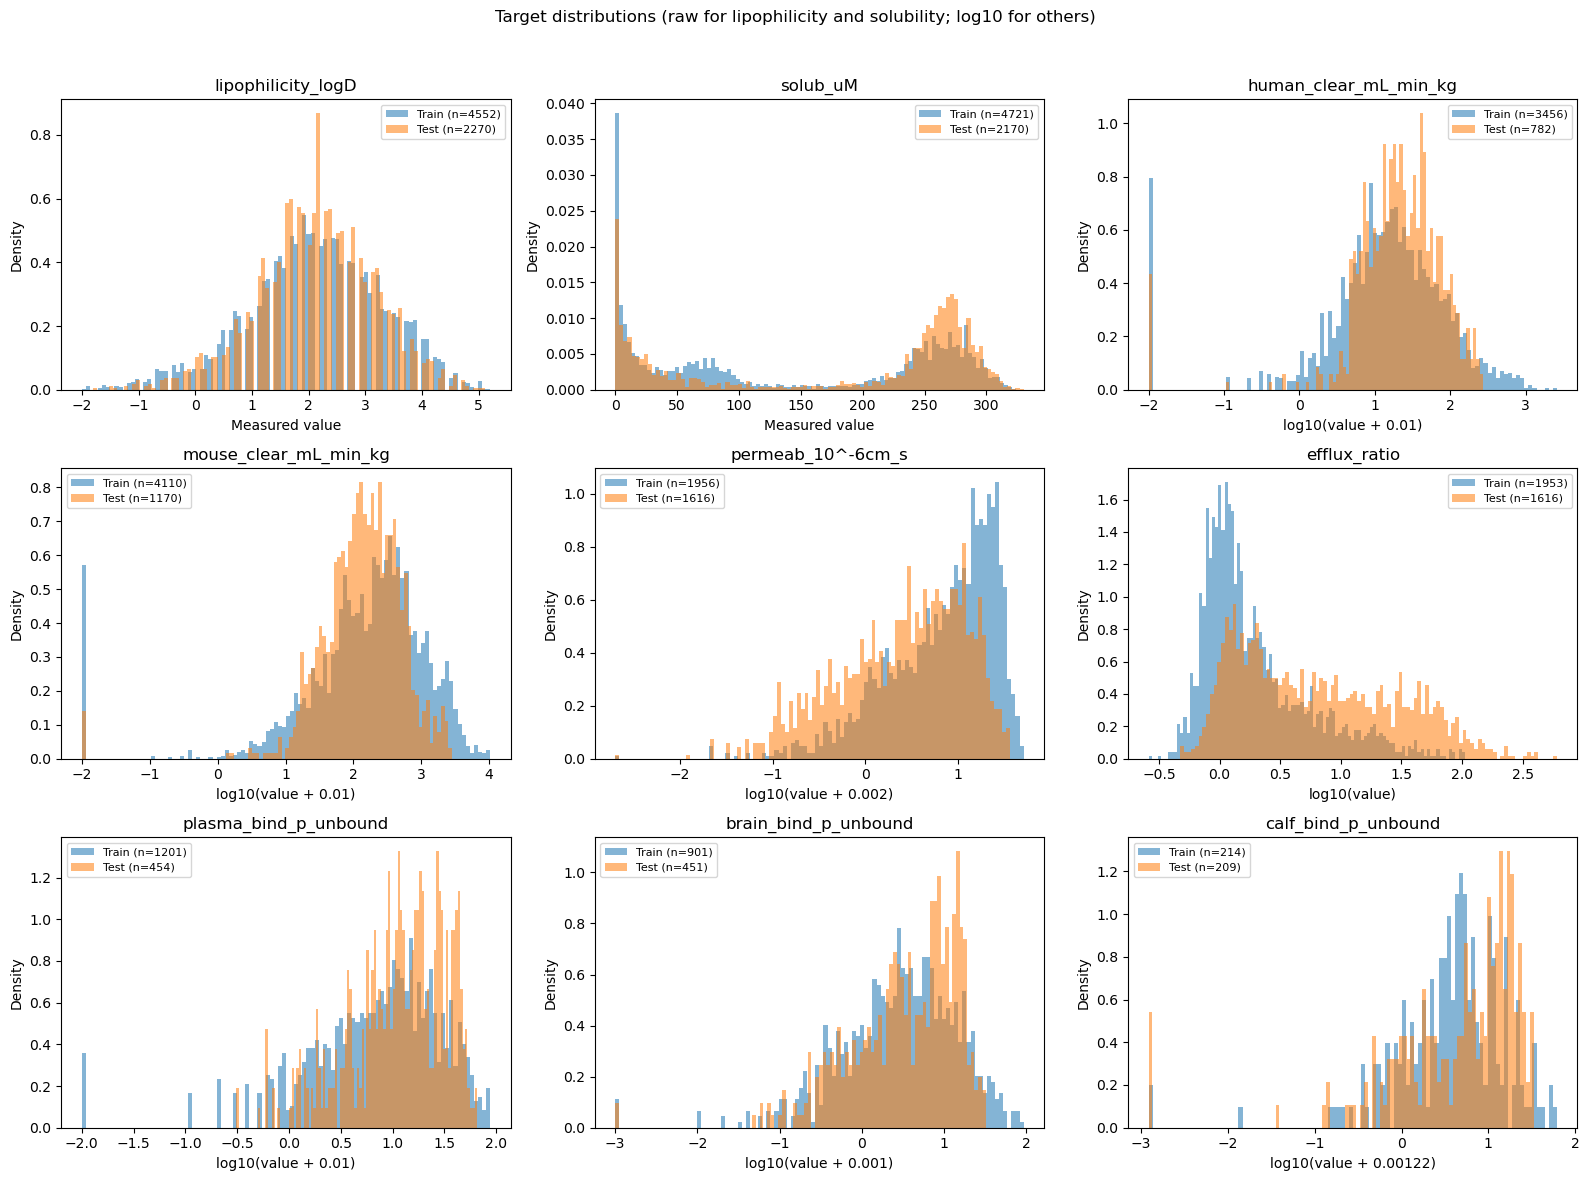

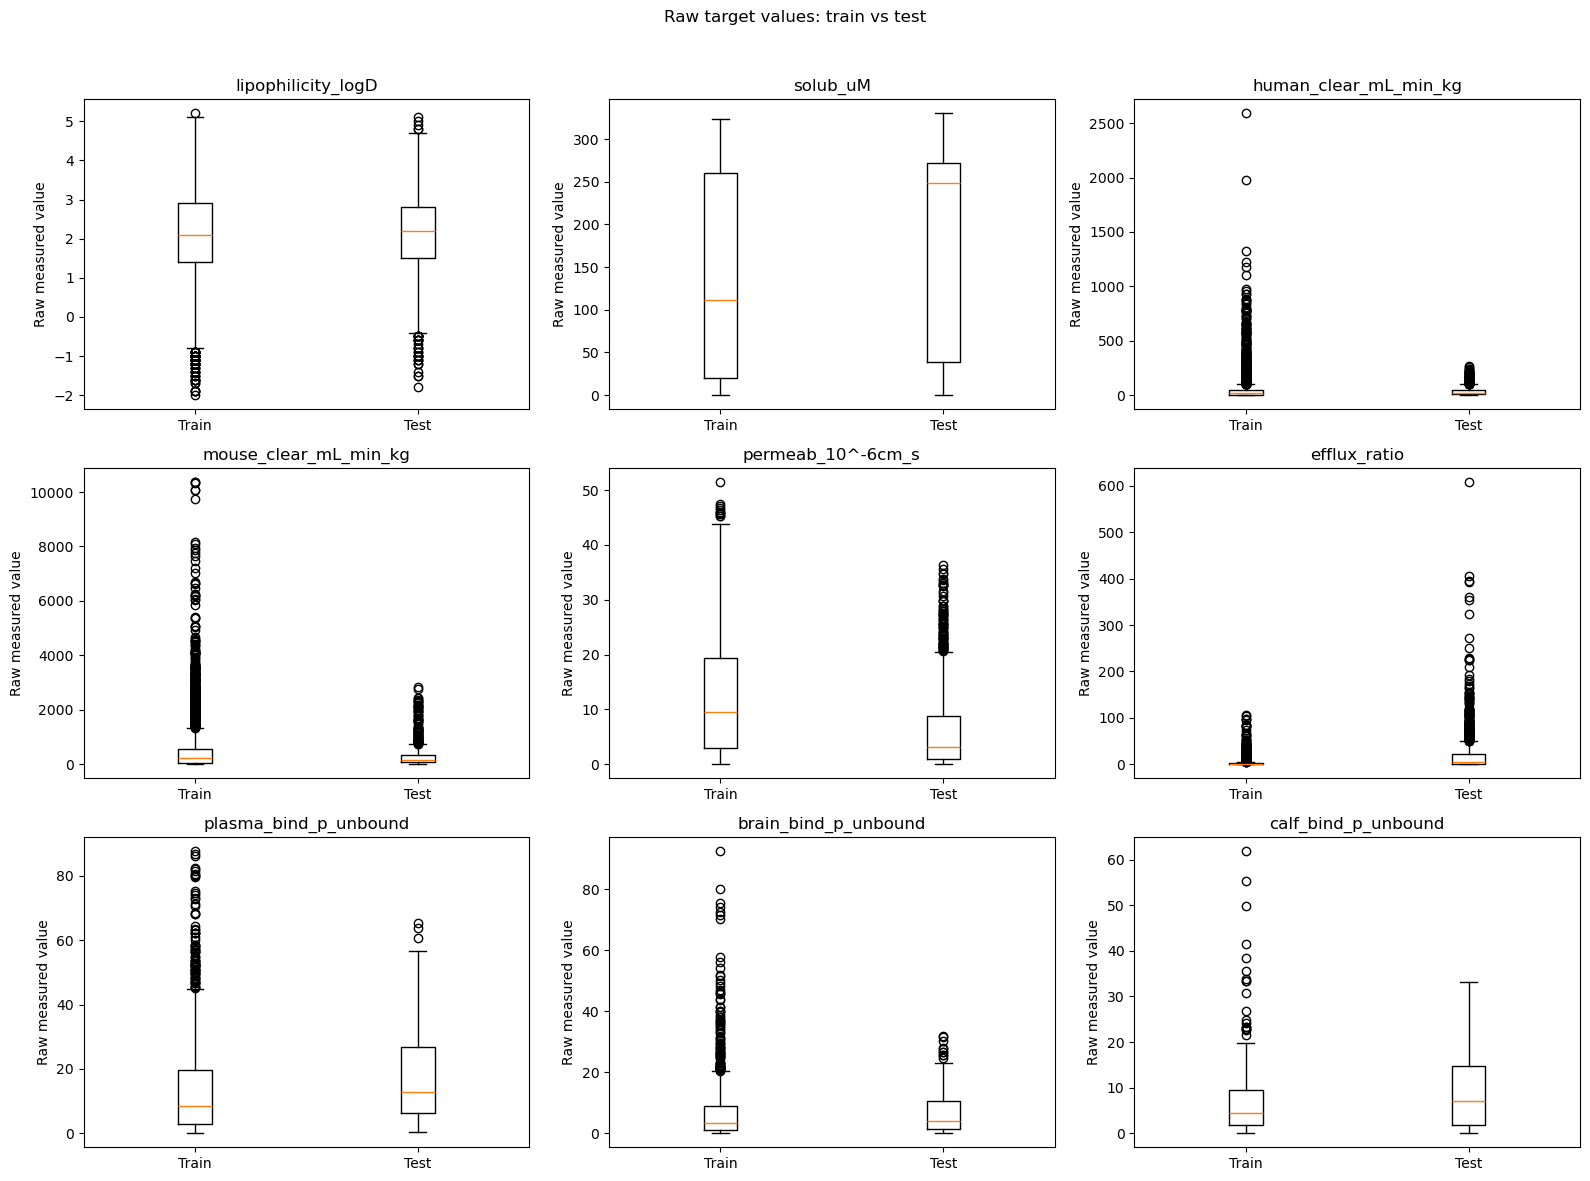

,train_min,test_min,train_zeros,test_zeros,train_max,test_max,train_max_n,test_max_n
target,,,,,,,,
lipophilicity_logD,-2.0000,-1.80000,0.461336,0.704846,5.20,5.10,1,1
solub_uM,0.0019,0.00129,0.000000,0.000000,324.00,330.00,1,1
human_clear_mL_min_kg,0.0000,0.00000,4.311343,1.918159,2589.90,271.50,1,1
mouse_clear_mL_min_kg,0.0000,0.00000,3.430657,0.769231,10354.80,2828.30,1,1
permeab_10^-6cm_s,0.0000,0.00000,0.051125,0.061881,51.41,36.28,1,1
efflux_ratio,0.2600,0.47000,0.000000,0.000000,105.64,607.29,1,1
plasma_bind_p_unbound,0.0000,0.30000,1.415487,0.000000,87.60,65.40,1,1
brain_bind_p_unbound,0.0000,0.00000,0.554939,0.443459,92.42,31.85,1,1
calf_bind_p_unbound,0.0000,0.00000,0.934579,2.392344,61.80,33.20,1,1


{'human_clear_mL_min_kg': np.float64(0.010000000000000002), 'mouse_clear_mL_min_kg': np.float64(0.010000000000000002), 'permeab_10^-6cm_s': np.float64(0.002), 'efflux_ratio': 0.0, 'plasma_bind_p_unbound': np.float64(0.010000000000000002), 'brain_bind_p_unbound': np.float64(0.001), 'calf_bind_p_unbound': np.float64(0.0012200000000000002)}


In [81]:
# TODO: check for censoring / ceiling effects in KSOL and the other endpoints.
# Keep lipophilicity and solubility raw; log10-transform the other targets.
RAW_TARGETS = {"lipophilicity_logD", "solub_uM"}
LOG_TARGETS = [target for target in TARGETS if target not in RAW_TARGETS]

# For targets with zeros, use half the smallest positive training value as c.
# Use the same c for test so the transform is determined from training data only.
log_offsets = {}
for target in LOG_TARGETS:
    positive_train = train.loc[train[target] > 0, target]
    log_offsets[target] = positive_train.min() * 0.1 if (train[target] == 0).any() else 0.0

train_plot = train[TARGETS].copy()
test_plot = test[TARGETS].copy()
for target in LOG_TARGETS:
    c = log_offsets[target]
    train_plot[target] = np.log10(train_plot[target] + c)
    test_plot[target] = np.log10(test_plot[target] + c)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, target in zip(axes.flat, TARGETS):
    train_values = train_plot[target].dropna()
    test_values = test_plot[target].dropna()
    ax.hist(train_values, bins=100, density=True, alpha=0.55, label=f"Train (n={len(train_values)})")
    ax.hist(test_values, bins=100, density=True, alpha=0.55, label=f"Test (n={len(test_values)})")
    ax.set_title(target)
    if target in LOG_TARGETS:
        c = log_offsets[target]
        ax.set_xlabel(f"log10(value + {c:g})" if c else "log10(value)")
    else:
        ax.set_xlabel("Measured value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Target distributions (raw for lipophilicity and solubility; log10 for others)")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# Compare raw train and test values with side-by-side box-and-whisker plots.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, target in zip(axes.flat, TARGETS):
    train_values = train[target].dropna()
    test_values = test[target].dropna()
    ax.boxplot([train_values, test_values], labels=["Train", "Test"])
    ax.set_title(target)
    ax.set_ylabel("Raw measured value")

fig.suptitle("Raw target values: train vs test")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# Summarize observed minima and exact-zero counts for each target.
summary_rows = []
for target in TARGETS:
    train_values = train[target].dropna()
    test_values = test[target].dropna()
    summary_rows.append({
        "target": target,
        "train_min": train_values.min(),
        "test_min": test_values.min(),
        "train_zeros": (train_values == 0).sum()/len(train_values)*100,
        "test_zeros": (test_values == 0).sum()/len(test_values)*100,
        "train_max": train_values.max(),
        "test_max": test_values.max(),
        "train_max_n": (train_values == train_values.max()).sum(),
        "test_max_n": (test_values == test_values.max()).sum(),
    })

target_bounds = pd.DataFrame(summary_rows).set_index("target")
display(target_bounds)
print(log_offsets)

### 3.2 Target distributions (train vs test)

**Prompts**
- Which endpoints are strongly right-skewed or heavy-tailed? Would you model them on a log scale (`log10(x + c)`)? How would you pick `c`, and how do you back-transform for reporting?

All but lipophilicity and solubility. Lipophilicity is already normally distributed, so doesn't need touching. Solubility is bimodal, log transforming this makes it extremly negatively skewed, which defeats (part of) the point of transformation, so it should be untouched. All others are extremely right skewed, log transforming these makes learning more stable (instead of being dominated by larger values) and makes predicted distributions more normally distributed, so should be applied. Choosing c depends on what 0 means for a particular target (c is there rescues log(0)). In these cases where 0 is a plausible for all targets whose min=0 (as in, there's no artifical flooring at 0 as a result of say, assay limitations), I think the smallest positive value * 0.1 is sensible because it doesn't break normality of the transformed distributions too much (see plots).

Backtransforming: if using MSE on log scale for loss, we can report error as "...in the order of +-10^(sqrt(MSE))". For individual data points we just reverse the log.

- Percent-unbound endpoints (`MPPB`, `MBPB`, `MGMB`) live in [0, 100] and are often tiny (highly bound compounds). Is a plain regression on the raw % sensible? Consider `log10(% unbound)` or a logit.

Log(unbound) is sensible and consistent with the transformation of others.. I don't see the advantage of logit over log for these.

- Does the **test distribution differ from train** for any endpoint (compare medians, tails)? What would that do to R² versus Spearman?

1. Going from train to test, solubility is much higher, permeability is much lower, 

In [ ]:
# TODO: quantify train/test shift per endpoint (e.g. KS statistic, median difference) and choose target transforms.

### 3.3 Chemical space and train→test similarity

**Prompts**
- How much does the test set resemble train? Is the split closer to random, scaffold, or temporal? (Molecule IDs such as `E-00xxxxx` reflect measurement order: use them to test whether the split is temporal.)
- Embed the combined set (PCA/UMAP of fingerprints) and colour by train/test and by a few endpoints. Are there test-only regions?
- Compute simple property distributions (MW, cLogP, TPSA, HBD) for train vs test.
- Choose how to effectively select portions of the train set

In [ ]:
# TODO: Tanimoto similarity, PCA/UMAP embedding, property distributions, any other EDA you find informative.

### 3.4 Endpoint relationships

**Prompts.** Which endpoints are strongly related? Which endpoints are expected to be related? How can this be used?

In [ ]:
# TODO: Correlation map, time dependence, and other visualizations to explore relationships between endpoints.

## 4. Featurization and model fitting

### 4.0 Shared helpers

Feature builders and a mask-aware metric function, so that the four models are compared on exactly the same footing.

In [ ]:
# TODO: create helpers such as fingerprints and featurization here

### 4.0.1 Validation protocol (decide this *before* fitting)

Build your CV folds here and use the **same folds for every model**. A random split is the weakest option given §3.3; consider scaffold-grouped or cluster-grouped (Butina / BitBIRCH) folds. Justify your choice using the train↔test similarity you measured.

In [ ]:
from sklearn.model_selection import GroupKFold

def make_folds(groups, n_splits=5):
    # TODO: replace with the split you would want
    return list(GroupKFold(n_splits=n_splits).split(np.zeros(len(groups)), groups=groups))

folds = make_folds(train["scaffold"].values)
[len(v) for _, v in folds]

### 4.0.2 Choose your metrics (decide this *before* fitting)

Also decide: the **scale** the error metrics are computed on (raw vs `log10`), how to **aggregate** across endpoints (per-endpoint reporting, macro-average of a unitless metric, ...), and how to report **uncertainty** (bootstrap CI, fold spread).

**Your metric choice and justification** (which metrics, on what scale, how aggregated, and why this is reasonable for *this* use-case, i.e. lead-optimisation compound prioritisation):

_TODO_

Pick your endpoint subset here. `KSOL` is in µM.

In [ ]:
METRICS_TO_REPORT = []   # TODO: your set, drawn from metrics() or your own additions
ENDPOINTS = ["LogD", "KSOL", "HLM CLint", "Caco-2 Permeability Papp A>B"]   # TODO: change / extend

### 4.1 Model A: Ridge regression

A regularised linear baseline. It is simple, fast, and tells you how much of the signal is (nearly) linear in the features.

**Suggestions**
- Compare feature sets: Morgan counts only, RDKit descriptors only, both. Standardise descriptors; impute missing values on train folds only.
- Tune `alpha` with *inner* CV (`RidgeCV` with the grouped folds), never on the test set.
- Report coefficients/most influential features for at least one endpoint. Do they make chemical sense?

In [ ]:
# TODO: fit Ridge per endpoint, produce out-of-fold predictions on train using `folds`.
# oof_ridge = {ep: np.full(len(train), np.nan) for ep in ENDPOINTS}

### 4.2 Model B: Boosted trees

LightGBM or XGBoost on the same features.

**Suggestions**
- Start with sensible defaults (`n_estimators` ≈ 500–1000, `learning_rate` ≈ 0.03–0.05, `num_leaves`/`max_depth` modest, `colsample_bytree` < 1, early stopping on an inner fold).
- Count fingerprints + RDKit descriptors usually beat bits alone. Test it.
- Keep tuning effort comparable to the other models; report how much you spent.

In [ ]:
# TODO: LightGBM / XGBoost per endpoint with the same folds.

### 4.3 Model C: Chemprop (D-MPNN)

Graph neural network that learns its own molecular representation.

**Chemprop on GitHub: <https://github.com/chemprop/chemprop>** (v2 docs: <https://chemprop.readthedocs.io>). Read the README sections on *training*, *multitask / missing targets*, and *adding extra descriptors*.

**Suggestions**
- Chemprop handles **missing labels natively** in multi-task mode (NaN targets are masked in the loss). Try a single multi-task model over all your endpoints vs one model per endpoint, and compare.
- Use the same train/validation folds as the other models. Chemprop's own `--split-type` is *not* a substitute; pass your explicit split indices.
- Apply the same target transforms (§4.0). Chemprop standardises targets internally (`--task-type regression`), but heavy-tailed raw targets still hurt.
- Try (a) default D-MPNN, (b) + RDKit/Morgan descriptors as extra molecule features, (c) any other features.
- GPU strongly recommended but a handful of epochs on CPU is fine for a first pass. We are not testing your hardware

Example CLI (check `chemprop train --help` for your installed version):
```bash
chemprop train --data-path data/train_fold0.csv --smiles-columns SMILES \
    --target-columns "LogD" "KSOL" "HLM CLint" \
    --task-type regression --epochs 50 --split-column split \
    --output-dir runs/chemprop_fold0
chemprop predict --test-path data/val_fold0.csv --model-paths runs/chemprop_fold0 \
    --smiles-columns SMILES --preds-path preds_fold0.csv
```

In [ ]:
# TODO: write per-fold CSVs (SMILES + transformed targets), train via CLI (subprocess / !chemprop) or the Python API,
# and collect out-of-fold predictions into the same structure as the other models.

### 4.4 Model D: your own choice

Pick *one* model family that is not Ridge, boosted trees or vanilla Chemprop, and say why you expect it to help on **this** data. Ideas (pick one, or propose your own):

State your hypothesis in one or two sentences *before* you run it.

**Your hypothesis for Model D:**

_TODO_

In [ ]:
# TODO: Model D

## 5. Model validation (cross-validation on train only)

Collect out-of-fold (OOF) predictions for all four models and compare them on the *same* folds.

In [ ]:
# Expected structure: oof[model_name][endpoint] -> np.ndarray of length len(train) (NaN where not predicted)
oof = {}   # TODO: fill, e.g. oof["ridge"] = {...}; oof["lgbm"] = {...}; oof["chemprop"] = {...}; oof["mine"] = {...}

def cv_table(oof):
    rows = []
    for model, per_ep in oof.items():
        for ep, pred in per_ep.items():
            rows.append({"model": model, "endpoint": ep, **metrics(train[ep], pred)})
    return pd.DataFrame(rows)

# cv_res = cv_table(oof); cv_res.pivot(index="endpoint", columns="model", values=METRICS_TO_REPORT[0]).round(3)

**Prompts**
- Report metric **and uncertainty** (fold-to-fold spread, or bootstrap CI on the OOF predictions). Are the differences between models larger than the noise?
- Do your chosen metrics (§4.0.2) agree on the model ranking? If they disagree (e.g. best MAE but worst Spearman), explain which you trust for the use-case and why.
- Compare a random-fold CV to your grouped CV for one model. How big is the optimism gap?
- Check calibration: plot OOF predicted vs measured for each endpoint.

In [ ]:
# TODO: CV comparison plots / tables, uncertainty estimates, random-vs-grouped CV gap.

## 6. Held-out performance

Now, and only now, refit the chosen configuration of each model on **all** of `train` and predict `test`. Do not change hyper-parameters after seeing these numbers; if you do, say so explicitly.

In [ ]:
test_pred = {}   # TODO: test_pred[model][endpoint] -> np.ndarray(len(test))

def test_table(test_pred):
    rows = []
    for model, per_ep in test_pred.items():
        for ep, pred in per_ep.items():
            rows.append({"model": model, "endpoint": ep, **metrics(test[ep], pred)})
    return pd.DataFrame(rows)

# test_res = test_table(test_pred); test_res.pivot(index="endpoint", columns="model", values=METRICS_TO_REPORT[0]).round(3)

**Prompts**
- Put CV and held-out numbers side by side. How large is the generalisation gap per endpoint and per model? Does the model ranking from CV hold on test?
- If a metric collapses on test while Spearman survives (e.g. negative R² but positive rank correlation), what does that tell you about the shift you found in §3.2? What would you do about it (recalibration on a few labelled compounds, shift-robust targets, ...)?
- Report all four models for every endpoint you chose, on the same compounds.

In [ ]:
# TODO: side-by-side CV vs held-out table and figure.

## 7. Analysis of strong and weak points
This is the most representative part of the daily workflow

### 7.1 Where do models succeed or fail?

In [ ]:
# Starter: error vs. distance to training set. Replace `pred` with a model's test predictions.
def error_vs_similarity(y_true, pred, nn_sim, n_bins=5):
    d = pd.DataFrame({"y": y_true, "p": pred, "sim": nn_sim}).dropna()
    d["bin"] = pd.qcut(d["sim"], n_bins, duplicates="drop")
    return d.groupby("bin").apply(lambda g: pd.Series({
        "n": len(g), "MAE": (g.y - g.p).abs().mean(),
        "Spearman": spearmanr(g.y, g.p)[0] if len(g) > 5 else np.nan}))

# error_vs_similarity(test["LogD"], test_pred["lgbm"]["LogD"], nn_te)

In [ ]:
# TODO: stratified error analysis, residual plots, worst-predicted structures, or any other analysis you find informative.

### 7.2 Comparing the four models

**Your analysis**:

1. **Accuracy.** Which model wins on which endpoint, and is the difference statistically meaningful? Is the extra complexity of Chemprop / your custom model justified over Ridge and boosted trees?
2. **Data efficiency.** How does performance depend on label count? (Compare dense `LogD`/`KSOL` against sparse `MPPB`/`MGMB`; optionally plot a learning curve.)
3. **Robustness to shift.** Which model degrades least from CV to held-out, and why do you think so?
4. **Cost.** Training time, inference time, hyper-parameter sensitivity, interpretability.
5. **Failure modes.** What would you *not* trust each model for?
6. **Data issues.** How did you treat censoring / out-of-range values, skewed targets, noise ceiling of the assays (replicate variability)? What is the upper bound on achievable performance?
7. **Next steps.** If you had another week and could add either more data, more features, or better validation, which would you choose and why?

## 8. Deliverables checklist

- [ ] EDA with findings that
- [ ] Documented target transforms and handling of skewed targets and censoring
- [ ] Metrics chosen up front and justified (§4.0.2)
- [ ] Grouped CV with the same folds for all four models, with uncertainty
- [ ] Ridge, boosted-tree, Chemprop and one custom model, on the same endpoints
- [ ] One-shot held-out evaluation, CV vs test side by side
- [ ] Strengths/weaknesses analysis (§7) with figures
- [ ] Notebook runs top-to-bottom from a clean kernel; seeds fixed

## References
- Chemprop: <https://github.com/chemprop/chemprop> · docs: <https://chemprop.readthedocs.io>
- Heid et al., *Chemprop: A Machine Learning Package for Chemical Property Prediction*, J. Chem. Inf. Model. 2024
- RDKit: <https://www.rdkit.org> · LightGBM: <https://lightgbm.readthedocs.io> · XGBoost: <https://xgboost.readthedocs.io>
- OpenADMET: <https://openadmet.org> · Challenge data card: <https://huggingface.co/datasets/openadmet/openadmet-expansionrx-challenge-train-data>